In [1]:
import pandas as pd
import os
import subprocess
from glob import glob
import duckdb
import os
import tempfile
from glob import glob
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import re

# Preparing input preseq reads counts

## RT

In [15]:
def save_preseq_input(folder_pattern):
    for file_path in glob(folder_pattern):
        print(file_path)

        out_file = os.path.join(os.path.dirname(file_path), "preseq_input.txt")

        # Create a temporary DuckDB file on scratch
        with tempfile.TemporaryDirectory() as tmpdir:
            db_path = os.path.join(tmpdir, "temp.duckdb")
            con = duckdb.connect(db_path)

            # Optional but recommended on HPC
            con.execute("PRAGMA threads=40;")
            con.execute("PRAGMA temp_directory='" + tmpdir + "';")

            con.execute(
                f"""
                COPY (
                    SELECT
                        SUM(reads) AS reads
                    FROM read_csv(
                        '{file_path}',
                        sep='\t',
                        header=true,
                        columns={{
                            'RPTR_BC': 'VARCHAR',
                            'UMI': 'VARCHAR',
                            'reads': 'BIGINT'
                        }}
                    )
                    GROUP BY RPTR_BC, UMI
                )
                TO '{out_file}'
                (HEADER false);
            """
            )

            con.close()


save_preseq_input(
    "/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_*/*per_umi.tsv"
)

/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_2_10_S10_R1_001_fastp/RPTR_2_10_S10_R1_001_fastp_reads_per_umi.tsv
/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_2_5_S9_R1_001_fastp/RPTR_2_5_S9_R1_001_fastp_reads_per_umi.tsv
/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_3_10_S17_R1_001_fastp/RPTR_3_10_S17_R1_001_fastp_reads_per_umi.tsv
/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_1_240_S7_R1_001_fastp/RPTR_1_240_S7_R1_001_fastp_reads_per_umi.tsv
/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_2_180_S13_R1_001_fastp/RPTR_2_180_S13_R1_001_fastp_reads_per_umi.tsv
/global/scratch/p

## Running preseq

In [3]:
# Path to your preseq binary in the conda env
preseq_bin = (
    "/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/conda/preseq/bin/preseq"
)

# Base directory containing umi_* folders
BASE_DIR = "/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/"

# Find all umi_* directories
umi_dirs = sorted(glob(os.path.join(BASE_DIR, "*RPTR*")))

print(f"Found {len(umi_dirs)} UMI directories")
umi_dirs

Found 21 UMI directories


['/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_1_0_S1_R1_001_fastp',
 '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_1_10_S3_R1_001_fastp',
 '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_1_15_S4_R1_001_fastp',
 '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_1_180_S6_R1_001_fastp',
 '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_1_240_S7_R1_001_fastp',
 '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_1_30_S5_R1_001_fastp',
 '/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/outpu

In [4]:
# Loop over directories and print preseq commands
for umi_dir in umi_dirs:
    input_file = os.path.join(umi_dir, "preseq_input.txt")
    output_file = os.path.join(umi_dir, "preseq_yield.txt")

    if not os.path.exists(input_file):
        print(f"Missing input: {input_file}")
        continue

    # Check if the input file is not empty
    if os.path.getsize(input_file) == 0:
        continue

    cmd = f"{preseq_bin} pop_size -V {input_file} -o {output_file}"
    print(f"{cmd}")

/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/conda/preseq/bin/preseq pop_size -V /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_1_0_S1_R1_001_fastp/preseq_input.txt -o /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_1_0_S1_R1_001_fastp/preseq_yield.txt
/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/conda/preseq/bin/preseq pop_size -V /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_1_10_S3_R1_001_fastp/preseq_input.txt -o /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_RPTR_1_10_S3_R1_001_fastp/preseq_yield.txt
/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/conda/preseq/bin/preseq pop_size -V /global/scratch/projects/fc_mvslab/OpenProjects/

# Analyzign files which worked

In [31]:
rep_regex = r"_RPTR_(\d+)_"
time_regex = r"RPTR_\d+_(\d+)_"

In [53]:
dfs = []  # Initialize an empty list to store dataframes

# Loop over directories and process preseq output files
for umi_dir in umi_dirs:
    output_file = os.path.join(
        umi_dir, "preseq_yield.txt"
    )  # Path to the preseq output file

    # Extract replicate and time information from the directory name using regex
    rep = re.search(rep_regex, umi_dir).group(1)
    time = re.search(time_regex, umi_dir).group(1)

    # Skip if the output file does not exist
    if not os.path.exists(output_file):
        continue

    # Read the preseq output file into a dataframe
    df = pd.read_csv(output_file, sep="\t").reset_index()

    # Rename columns for clarity
    df.columns = ["pop_size_estimate", "lower_ci", "upper_ci", "converged"]

    # Add replicate and time information to the dataframe
    df["rep"] = int(rep)
    df["time"] = (int)(time)  # Convert time to integer for easier plotting

    # Append the dataframe to the list
    dfs.append(df)

# Concatenate all dataframes into a single dataframe
df = pd.concat(dfs).reset_index(drop=True).sort_values(by=["rep", "time"])
df

,pop_size_estimate,lower_ci,upper_ci,converged,rep,time
0,1.411479e+08,65567933.4,2.068118e+09,not_converged,1,0
6,1.882170e+08,132109995.7,6.473644e+08,not_converged,1,5
1,4.103997e+08,318340893.3,2.067977e+09,not_converged,1,10
2,3.611551e+08,294169353.8,6.850845e+08,not_converged,1,15
5,5.550410e+08,454734221.6,3.100442e+09,not_converged,1,30
3,1.074258e+09,513544449.5,7.337379e+09,not_converged,1,180
4,6.716922e+08,562754806.9,3.249165e+09,not_converged,1,240
7,1.861713e+08,69585119.9,4.096803e+09,not_converged,2,0
13,2.301726e+08,148158080.0,1.864528e+09,not_converged,2,5
8,5.217352e+08,291521856.6,3.461668e+09,not_converged,2,10


In [103]:
df.pivot(index = ['rep'], columns = ['time'], values = 'pop_size_estimate')

time,0,5,10,15,30,180,240
rep,,,,,,,
1,141147872.7,188217015.1,410399668.5,361155110.7,555041009.6,1.074258e+09,671692203.5
2,186171304.0,230172559.4,521735179.4,599477049.7,593817269.6,7.816915e+08,667636648.3
3,114828274.9,195508208.8,340747431.2,451457308.9,442277790.8,7.398921e+08,690442020.1


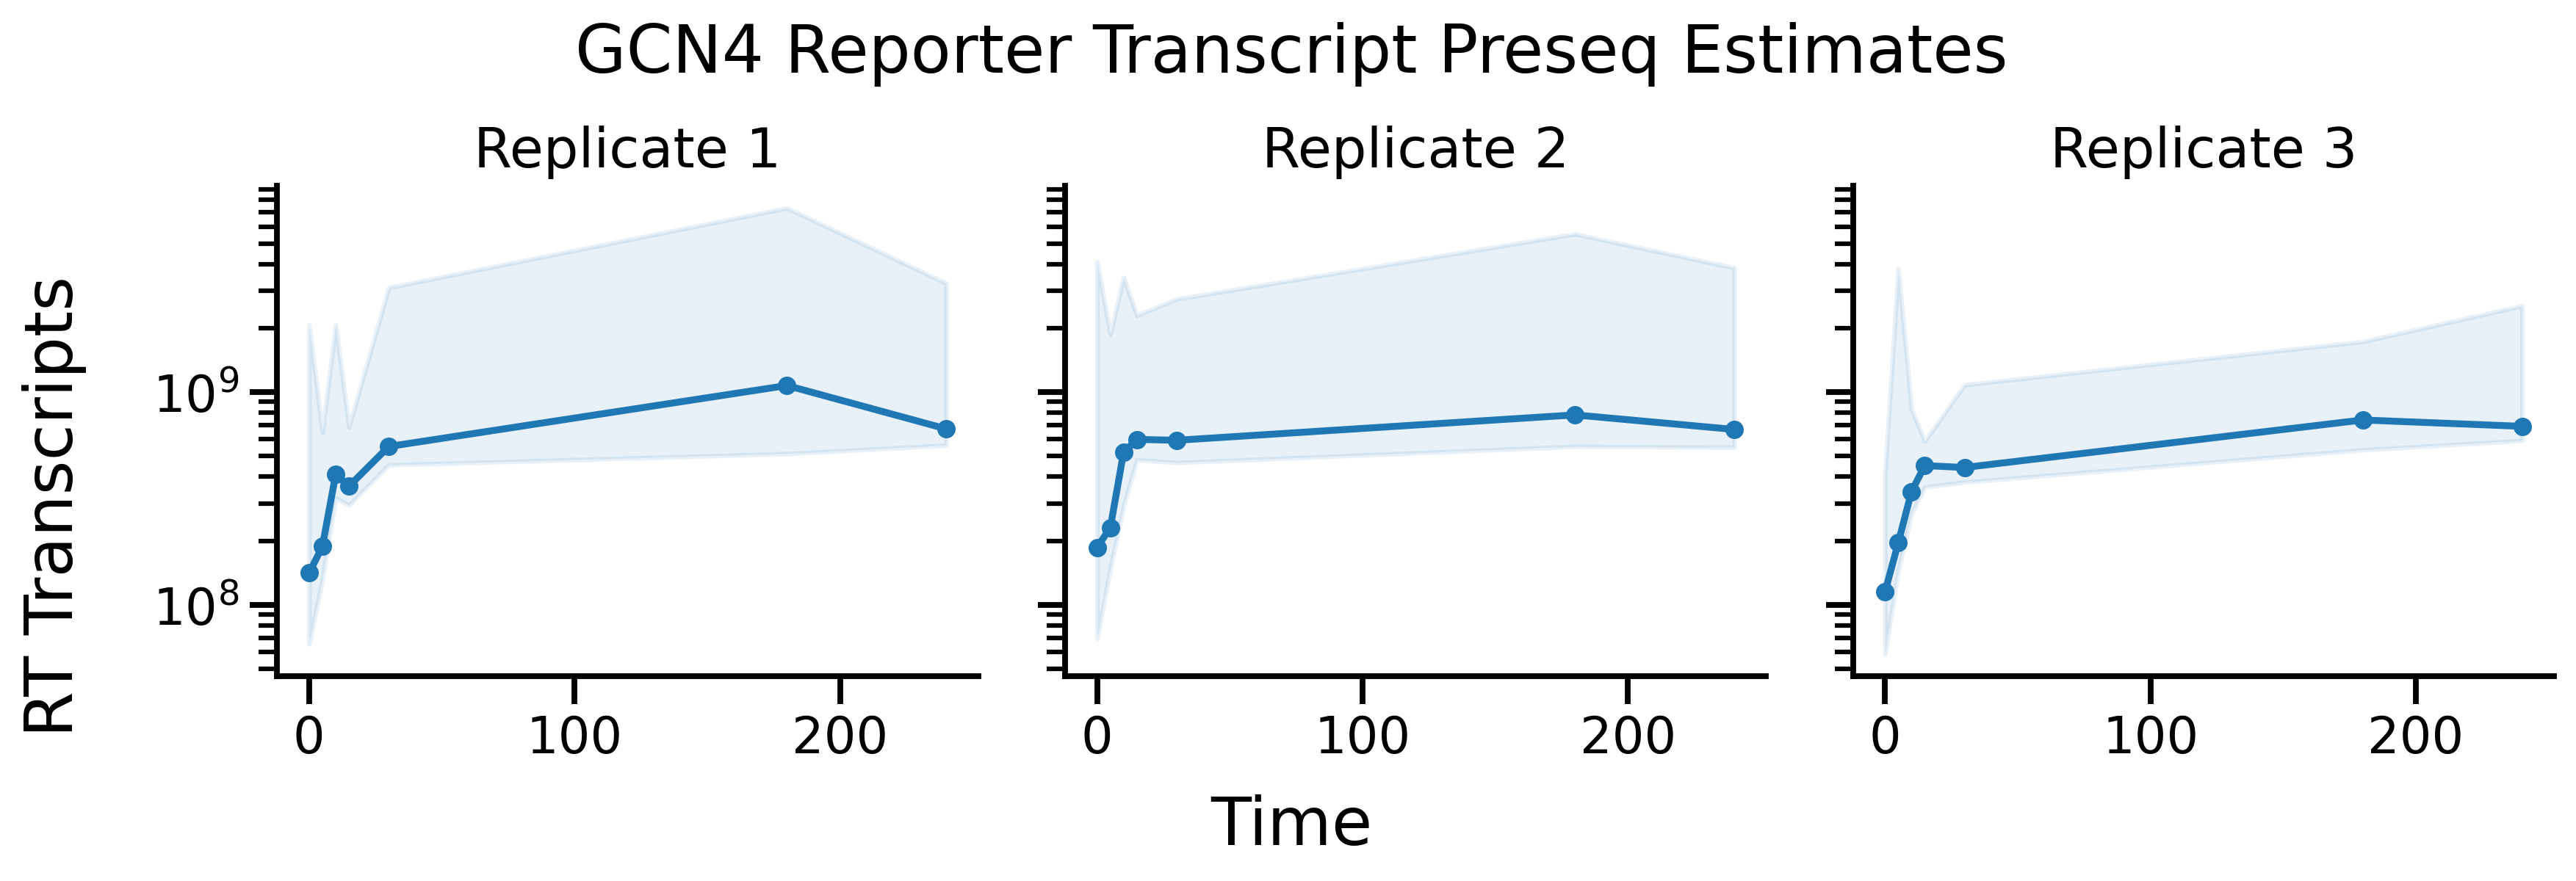

In [54]:
sns.set_context('talk')

n_reps = 3

# Create one row with three subplots (1 row, 3 columns)
fig, axes = plt.subplots(
    1, n_reps, figsize=(4 * n_reps, 4), sharex=True, sharey=True, dpi=300
)

if n_reps == 1:
    axes = [axes]  # Ensure axes is iterable even if only one rep

reps = np.arange(1, n_reps + 1)  # Assuming replicates are numbered from 1 to n_reps
for ax, rep in zip(axes, reps):
    g = df[df["rep"] == rep].sort_values("time")

    # Line for pop_size_estimate
    ax.plot(
        g["time"],
        g["pop_size_estimate"],
        color="C0",
        label=f"Rep {rep}",
        marker="o",
        markersize=5,
    )

    # Fill CI region
    ax.fill_between(g["time"], g["lower_ci"], g["upper_ci"], color="C0", alpha=0.1)

    ax.set_title(f"Replicate {rep}")
    ax.set_yscale("log")


fig.supxlabel("Time", y=0.1)
fig.supylabel("RT Transcripts", x=0.02)
plt.tight_layout()
sns.despine()
fig.suptitle("GCN4 Reporter Transcript Preseq Estimates", y=1.05)
plt.show()

# AD

In [26]:
def save_preseq_input_ad(folder_pattern):
    """
    Save Preseq-compatible input files for AD experiments.
    Aggregates reads per AD_BC + UMI and writes only counts.
    """
    for file_path in glob(folder_pattern):
        print(f"Processing: {file_path}")

        out_file = os.path.join(os.path.dirname(file_path), "preseq_input.txt")

        with tempfile.TemporaryDirectory() as tmpdir:
            con = duckdb.connect(os.path.join(tmpdir, "temp.duckdb"))
            con.execute("PRAGMA threads=40;")
            con.execute(f"PRAGMA temp_directory='{tmpdir}';")

            # Sum reads per AD_BC + UMI
            con.execute(f"""
                COPY (
                    SELECT SUM(reads) AS reads
                    FROM read_csv(
                        '{file_path}',
                        sep='\t',
                        header=True,
                        columns={{
                            'AD': 'VARCHAR',
                            'AD_BC': 'VARCHAR',
                            'UMI': 'VARCHAR',
                            'reads': 'BIGINT'
                        }}
                    )
                    GROUP BY AD, AD_BC, UMI
                )
                TO '{out_file}'
                (HEADER false);
            """)

            con.close()


In [27]:
# Make preseq input
save_preseq_input_ad(
    "/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_AD*/*per_umi.tsv"
)

Processing: /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_AD_1_0/AD_1_0_reads_per_umi.tsv
Processing: /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_AD_3_30/AD_3_30_reads_per_umi.tsv
Processing: /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_AD_1_15/AD_1_15_reads_per_umi.tsv
Processing: /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_AD_1_180/AD_1_180_reads_per_umi.tsv
Processing: /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_AD_2_240/AD_2_240_reads_per_umi.tsv
Processing: /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_AD_2_1

In [28]:
# Find all umi_* directories
AD_umi_dirs = sorted(glob(os.path.join(BASE_DIR, "*AD*")))
print(f"Found {len(AD_umi_dirs)} UMI directories")

Found 21 UMI directories


In [29]:
# Loop over directories and print preseq commands
for umi_dir in AD_umi_dirs:
    input_file = os.path.join(umi_dir, "preseq_input.txt")
    output_file = os.path.join(umi_dir, "preseq_yield.txt")

    if not os.path.exists(input_file):
        print(f"Missing input: {input_file}")
        continue

    # Check if the input file is not empty
    if os.path.getsize(input_file) == 0:
        continue

    cmd = f"{preseq_bin} pop_size -V {input_file} -o {output_file}"
    print(f"{cmd}")

/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/conda/preseq/bin/preseq pop_size -V /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_AD_1_0/preseq_input.txt -o /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_AD_1_0/preseq_yield.txt
/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/conda/preseq/bin/preseq pop_size -V /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_AD_1_10/preseq_input.txt -o /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C_umi_AD_1_10/preseq_yield.txt
/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/conda/preseq/bin/preseq pop_size -V /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4/yeast_pool_C_umi/trebl_experiment_yeast_pool_C

In [42]:
# Parse output
dfs = []  # Initialize an empty list to store dataframes

# Loop over directories and process preseq output files
for umi_dir in AD_umi_dirs:
    output_file = os.path.join(
        umi_dir, "preseq_yield.txt"
    )  # Path to the preseq output file
    
    # Skip if the output file does not exist
    if not os.path.exists(output_file):
        continue

    # Extract replicate and time information from the directory name using regex
    rep = re.search(r'AD_(\d+)_', umi_dir).group(1)
    time = re.search(r'AD_\d+_(\d+)', umi_dir).group(1)


    # Read the preseq output file into a dataframe
    df = pd.read_csv(output_file, sep="\t")

    # Add replicate and time information to the dataframe
    df["rep"] = int(rep)
    df["time"] = (int)(time)  # Convert time to integer for easier plotting

    # Append the dataframe to the list
    dfs.append(df)

# Concatenate all dataframes into a single dataframe
AD_df = pd.concat(dfs).sort_values(by=["rep", "time"]).reset_index(drop=True)
AD_df

,pop_size_estimate,lower_ci,upper_ci,rep,time
0,13856276.5,10253555.5,15598917.1,1,0
1,14458222.2,10768754.2,16345091.7,1,5
2,14739967.9,12152555.2,19026489.8,1,10
3,11722134.3,9418236.1,13105713.7,1,15
4,14041660.8,11365888.7,16909085.5,1,30
5,15267786.6,12591072.7,18849104.5,1,180
6,16305573.2,13449213.2,17300671.4,1,240
7,14239829.4,11463355.3,15725991.2,2,0
8,14289007.3,12045175.5,16628934.7,2,5
9,13884127.1,12656093.3,16499957.7,2,10


In [104]:
AD_df.pivot(index = ['rep'], columns = ['time'], values = 'pop_size_estimate')

time,0,5,10,15,30,180,240
rep,,,,,,,
1,13856276.5,14458222.2,14739967.9,11722134.3,14041660.8,15267786.6,16305573.2
2,14239829.4,14289007.3,13884127.1,14886908.4,14383483.6,15343981.0,15595136.6
3,15965104.9,12267046.8,12600822.9,13519996.1,12198956.6,12816272.8,14272896.5


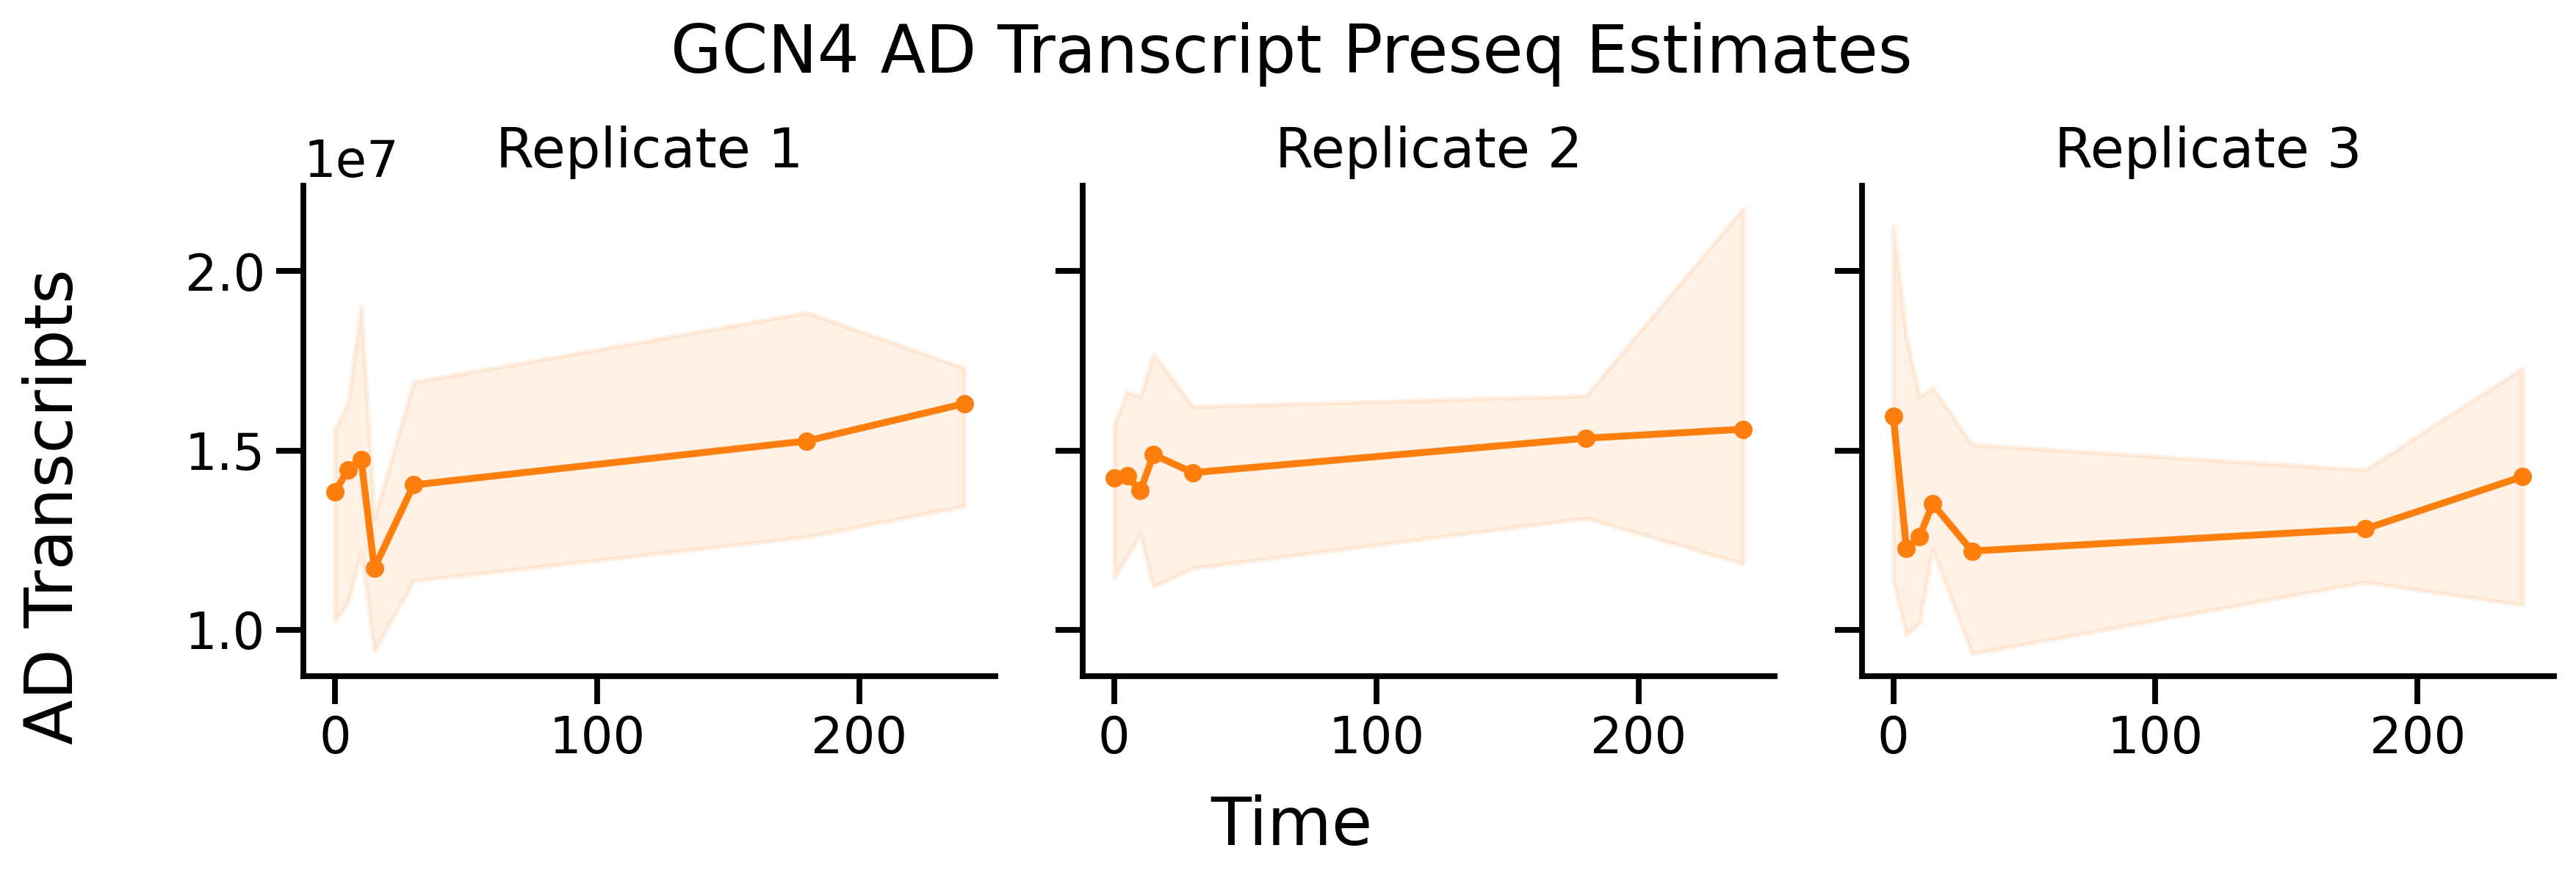

In [51]:
# Plot time courses
sns.set_context('talk')

n_reps = 3

# Create one row with three subplots (1 row, 3 columns)
fig, axes = plt.subplots(
    1, n_reps, figsize=(4 * n_reps, 4), sharex=True, sharey=True, dpi=300
)

if n_reps == 1:
    axes = [axes]  # Ensure axes is iterable even if only one rep

reps = np.arange(1, n_reps + 1)  # Assuming replicates are numbered from 1 to n_reps
for ax, rep in zip(axes, reps):
    g = AD_df[AD_df["rep"] == rep].sort_values("time")

    # Line for pop_size_estimate
    ax.plot(
        g["time"],
        g["pop_size_estimate"],
        color="C1",
        label=f"Rep {rep}",
        marker="o",
        markersize=5,
    )

    # Fill CI region
    ax.fill_between(g["time"], g["lower_ci"], g["upper_ci"], color="C1", alpha=0.1)

    ax.set_title(f"Replicate {rep}")
    #ax.set_yscale("log")


fig.supxlabel("Time", y=0.1)
fig.supylabel("AD Transcripts", x=0.02)
plt.tight_layout()
sns.despine()
fig.suptitle("GCN4 AD Transcript Preseq Estimates", y=1.05)
plt.show()

# Plotting AD and RT together

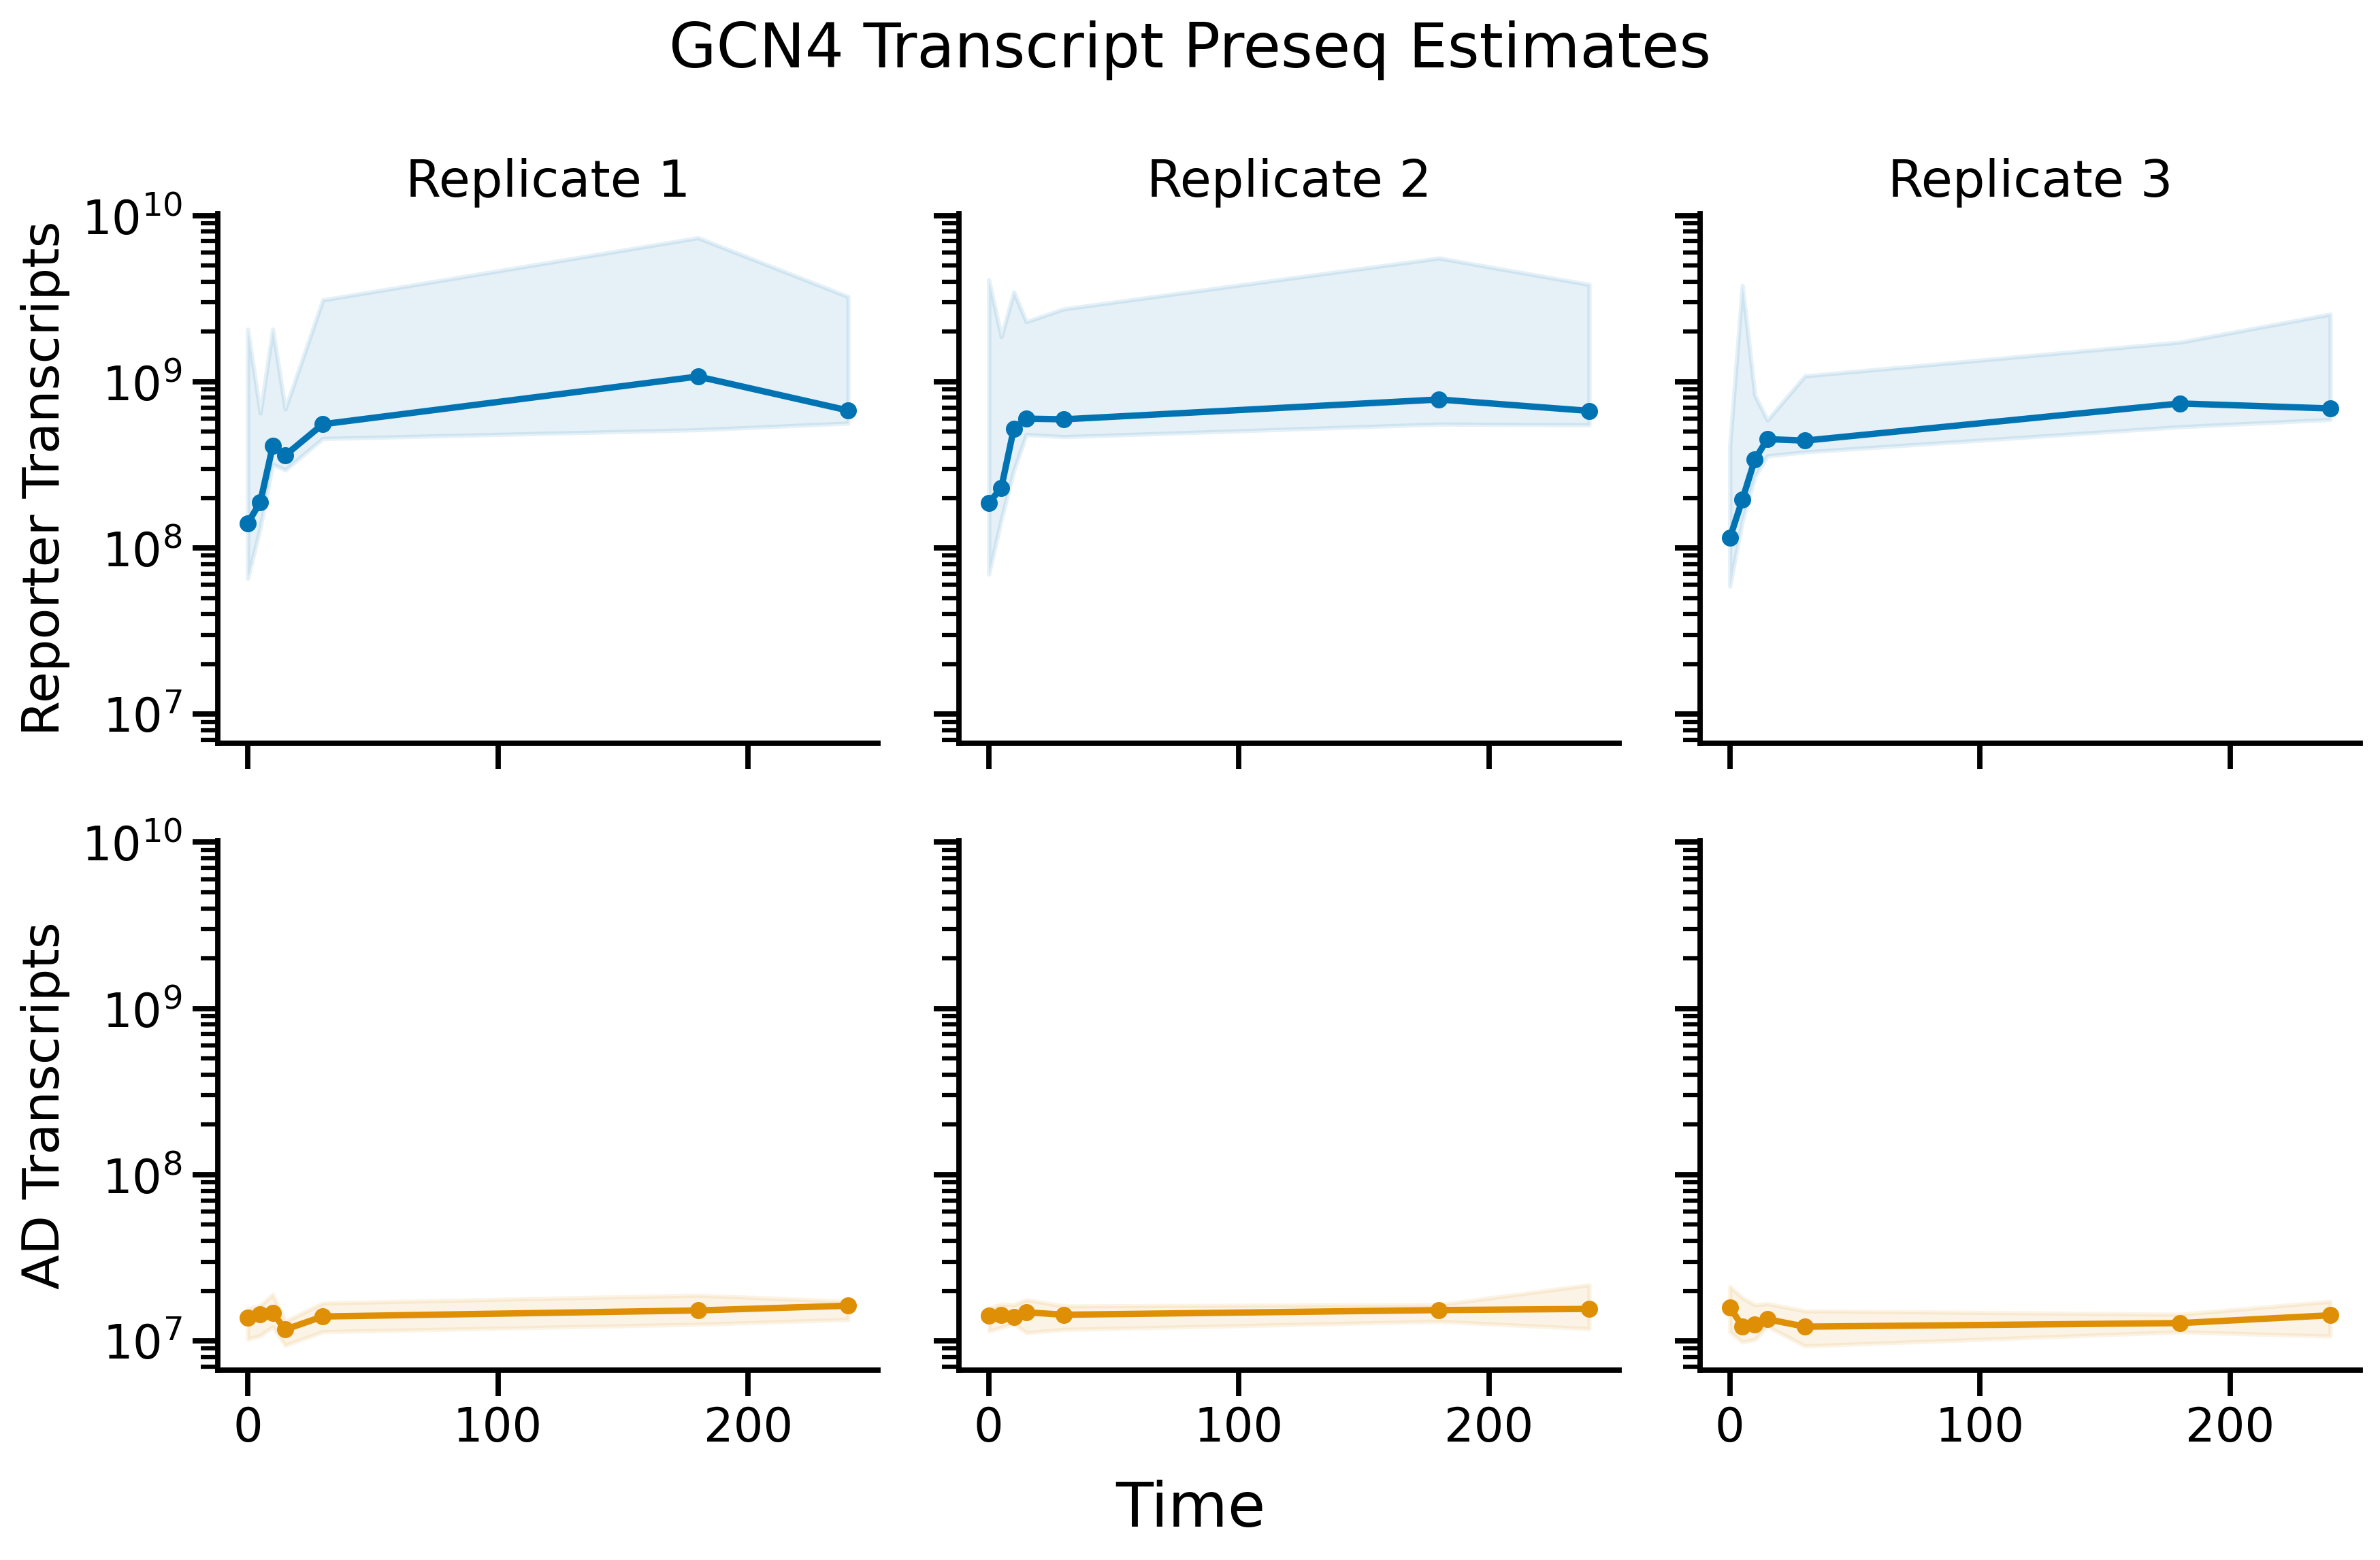

In [69]:
sns.set_context("talk")
palette = sns.color_palette("colorblind")

n_reps = 3
eps = 0  # pseudocount to avoid log(0)

fig, axes = plt.subplots(
    2, n_reps, figsize=(4 * n_reps, 8), sharex=True, sharey=True, dpi=300
)

# Ensure axes is 2D array for easy indexing
if n_reps == 1:
    axes = np.array([[axes[0]], [axes[1]]])
    
# ---- Top row: RT ----
for col, rep in enumerate(range(1, n_reps + 1)):
    ax = axes[0, col]
    g = df[df["rep"] == rep].sort_values("time")

    ax.plot(
        g["time"],
        g["pop_size_estimate"] + eps,
        color=palette[0],
        marker="o",
        markersize=5,
        label=f"Rep {rep}"
    )
    ax.fill_between(
        g["time"],
        g["lower_ci"] + eps,
        g["upper_ci"] + eps,
        color=palette[0],
        alpha=0.1
    )
    ax.set_yscale("log")
    ax.set_title(f"Replicate {rep}")
    
# ---- Bottom row: AD ----
for col, rep in enumerate(range(1, n_reps + 1)):
    ax = axes[1, col]
    g = AD_df[AD_df["rep"] == rep].sort_values("time")

    ax.plot(
        g["time"],
        g["pop_size_estimate"] + eps,
        color=palette[1],
        marker="o",
        markersize=5,
        label=f"Rep {rep}"
    )
    ax.fill_between(
        g["time"],
        g["lower_ci"] + eps,
        g["upper_ci"] + eps,
        color=palette[1],
        alpha=0.1
    )
    ax.set_yscale("log")
    #ax.set_title(f"Replicate {rep}")

axes[0,0].set_ylabel("Reporter Transcripts")
axes[1,0].set_ylabel("AD Transcripts")

# Global labels
fig.supxlabel("Time", y=0.05)
#fig.supylabel("Transcripts (log scale)", x=0.02)
fig.suptitle("GCN4 Transcript Preseq Estimates", y=0.98)

plt.tight_layout()
sns.despine()
plt.show()

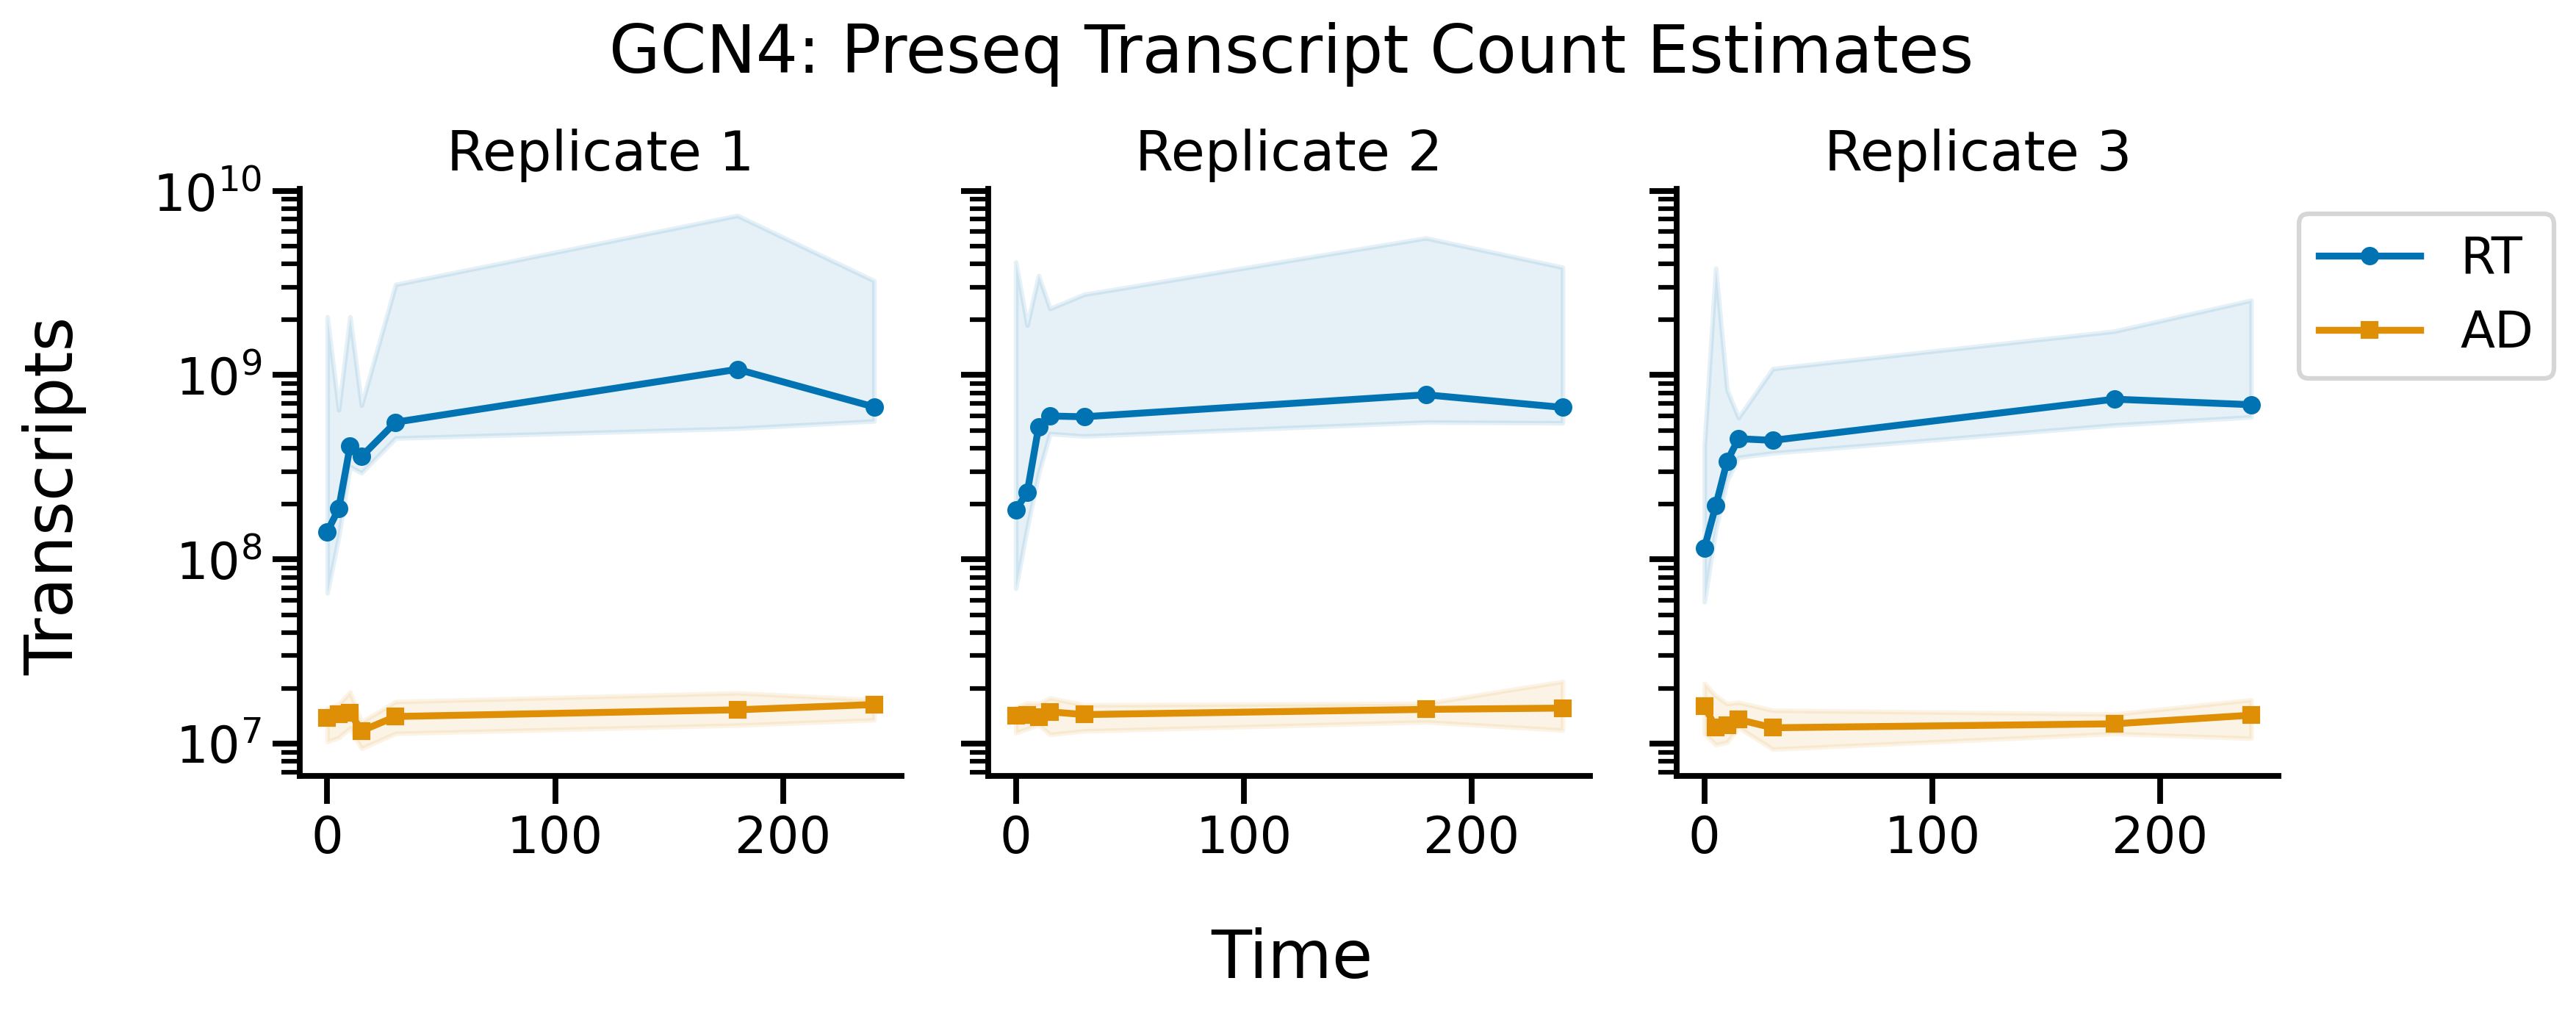

In [99]:
sns.set_context("talk")
palette = sns.color_palette("colorblind")

n_reps = 3
eps = 0  # pseudocount to avoid log(0)

fig, axes = plt.subplots(
    1, n_reps, figsize=(4 * n_reps, 5), sharex=True, sharey=True, dpi=300
)

if n_reps == 1:
    axes = [axes]

for ax, rep in zip(axes, range(1, n_reps + 1)):
    # RT
    g_rt = df[df["rep"] == rep].sort_values("time")
    ax.plot(
        g_rt["time"],
        g_rt["pop_size_estimate"] + eps,
        color=palette[0],
        marker="o",
        markersize=5,
        label="RT"
    )
    ax.fill_between(
        g_rt["time"],
        g_rt["lower_ci"] + eps,
        g_rt["upper_ci"] + eps,
        color=palette[0],
        alpha=0.1
    )

    # AD
    g_ad = AD_df[AD_df["rep"] == rep].sort_values("time")
    ax.plot(
        g_ad["time"],
        g_ad["pop_size_estimate"] + eps,
        color=palette[1],
        marker="s",
        markersize=5,
        label="AD"
    )
    ax.fill_between(
        g_ad["time"],
        g_ad["lower_ci"] + eps,
        g_ad["upper_ci"] + eps,
        color=palette[1],
        alpha=0.1
    )

    ax.set_yscale("log")
    ax.set_title(f"Replicate {rep}")

# Global labels
fig.supxlabel("Time", y=0.05)
fig.supylabel("Transcripts", x=0.02)
fig.suptitle("GCN4: Preseq Transcript Count Estimates", y=0.93)

# Legend (only once)
axes[2].legend(loc="upper right",bbox_to_anchor = (1.5,1))

plt.tight_layout()
sns.despine()
plt.show()

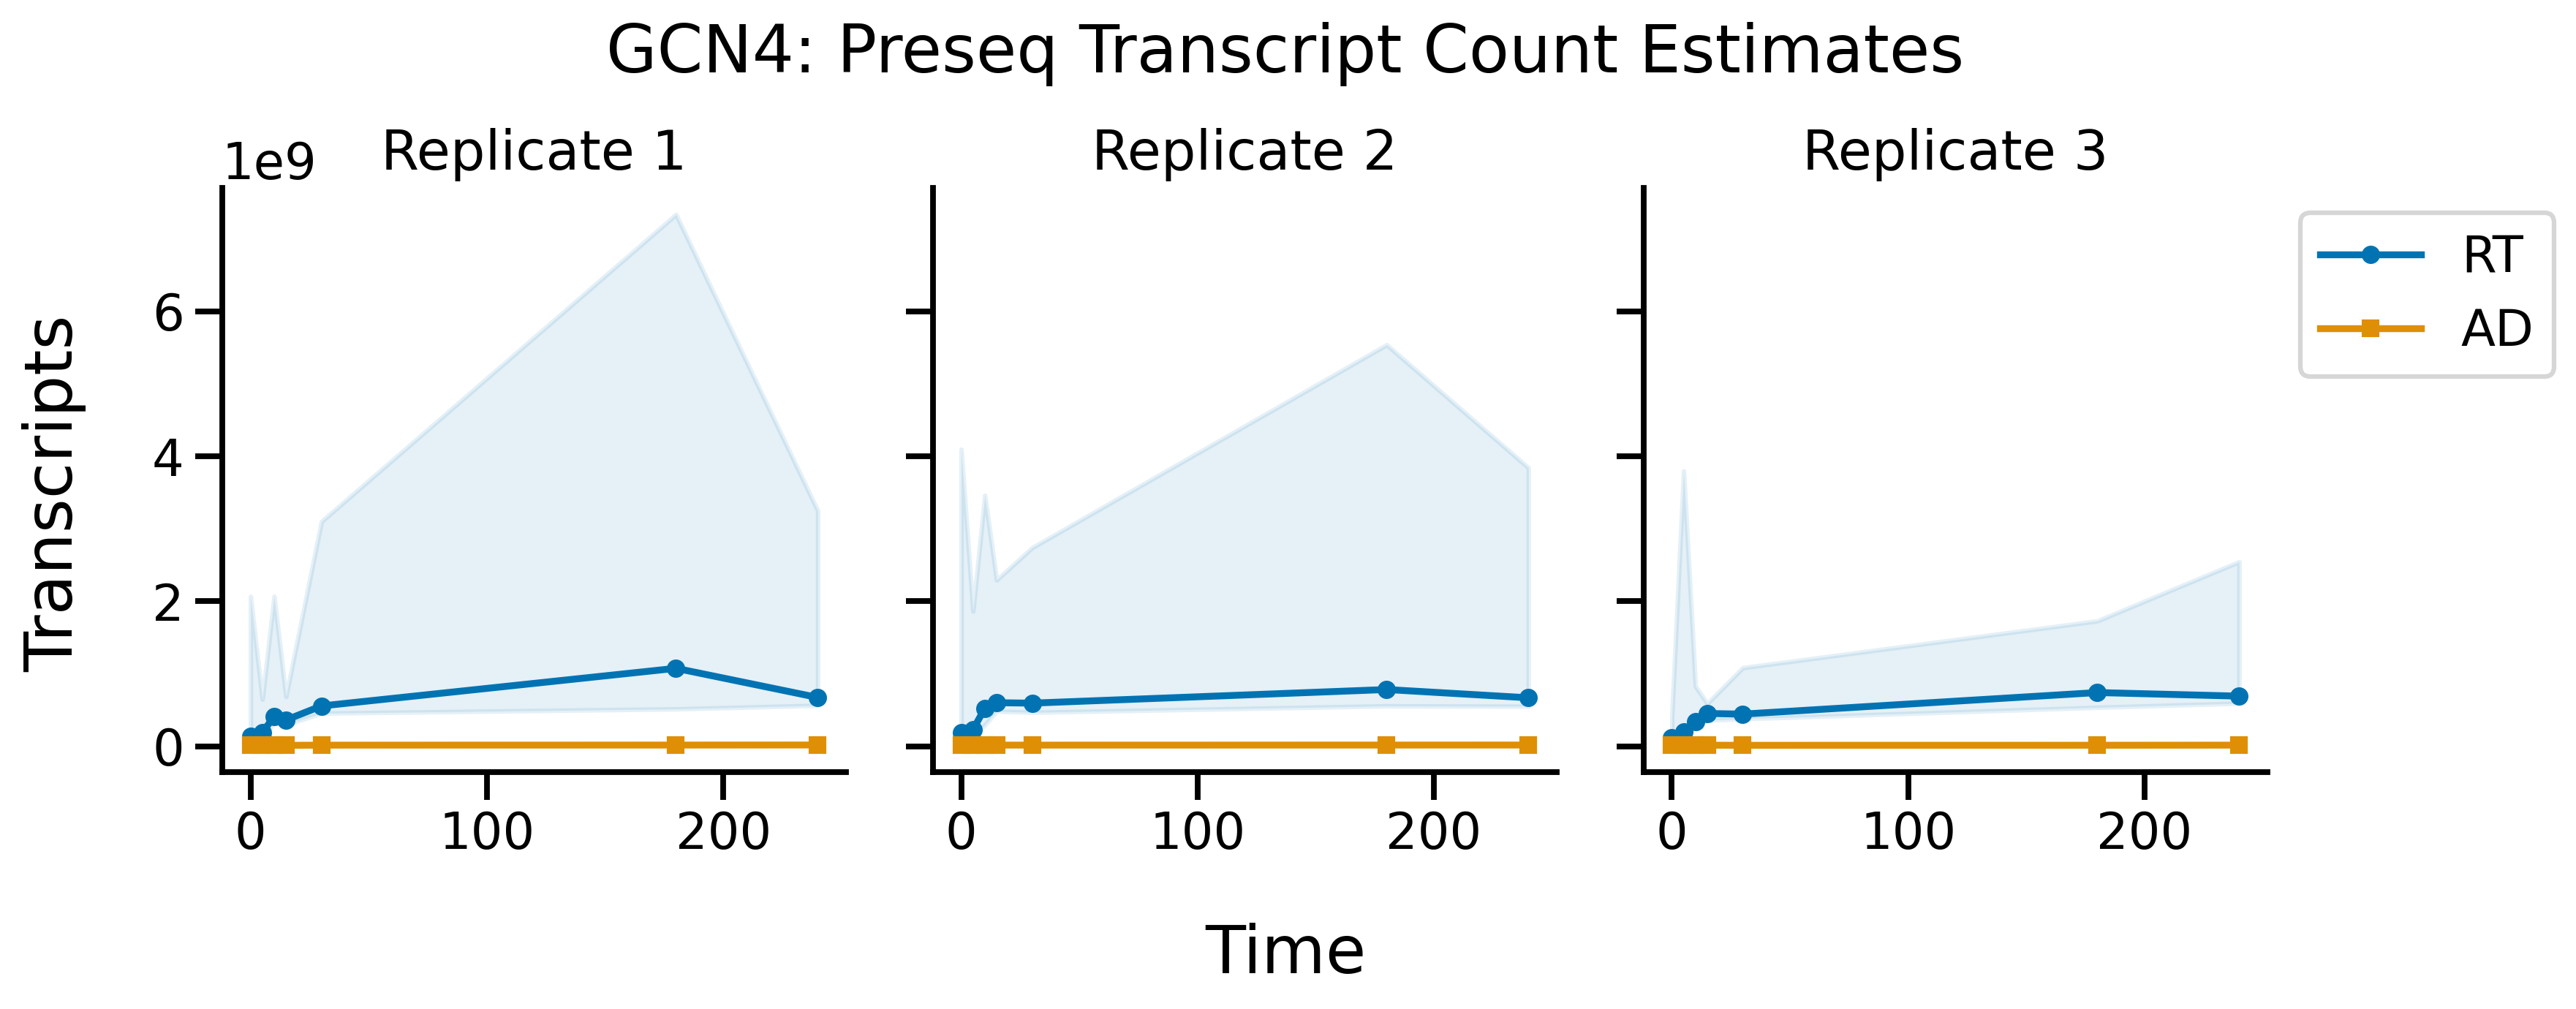

In [100]:
sns.set_context("talk")
palette = sns.color_palette("colorblind")

n_reps = 3
eps = 0  # pseudocount to avoid log(0)

fig, axes = plt.subplots(
    1, n_reps, figsize=(4 * n_reps, 5), sharex=True, sharey=True, dpi=300
)

if n_reps == 1:
    axes = [axes]

for ax, rep in zip(axes, range(1, n_reps + 1)):
    # RT
    g_rt = df[df["rep"] == rep].sort_values("time")
    ax.plot(
        g_rt["time"],
        g_rt["pop_size_estimate"] + eps,
        color=palette[0],
        marker="o",
        markersize=5,
        label="RT"
    )
    ax.fill_between(
        g_rt["time"],
        g_rt["lower_ci"] + eps,
        g_rt["upper_ci"] + eps,
        color=palette[0],
        alpha=0.1
    )

    # AD
    g_ad = AD_df[AD_df["rep"] == rep].sort_values("time")
    ax.plot(
        g_ad["time"],
        g_ad["pop_size_estimate"] + eps,
        color=palette[1],
        marker="s",
        markersize=5,
        label="AD"
    )
    ax.fill_between(
        g_ad["time"],
        g_ad["lower_ci"] + eps,
        g_ad["upper_ci"] + eps,
        color=palette[1],
        alpha=0.1
    )

    #ax.set_yscale("log")
    ax.set_title(f"Replicate {rep}")

# Global labels
fig.supxlabel("Time", y=0.05)
fig.supylabel("Transcripts", x=0.02)
fig.suptitle("GCN4: Preseq Transcript Count Estimates", y=0.93)

# Legend (only once)
axes[2].legend(loc="upper right",bbox_to_anchor = (1.5,1))

plt.tight_layout()
sns.despine()
plt.show()

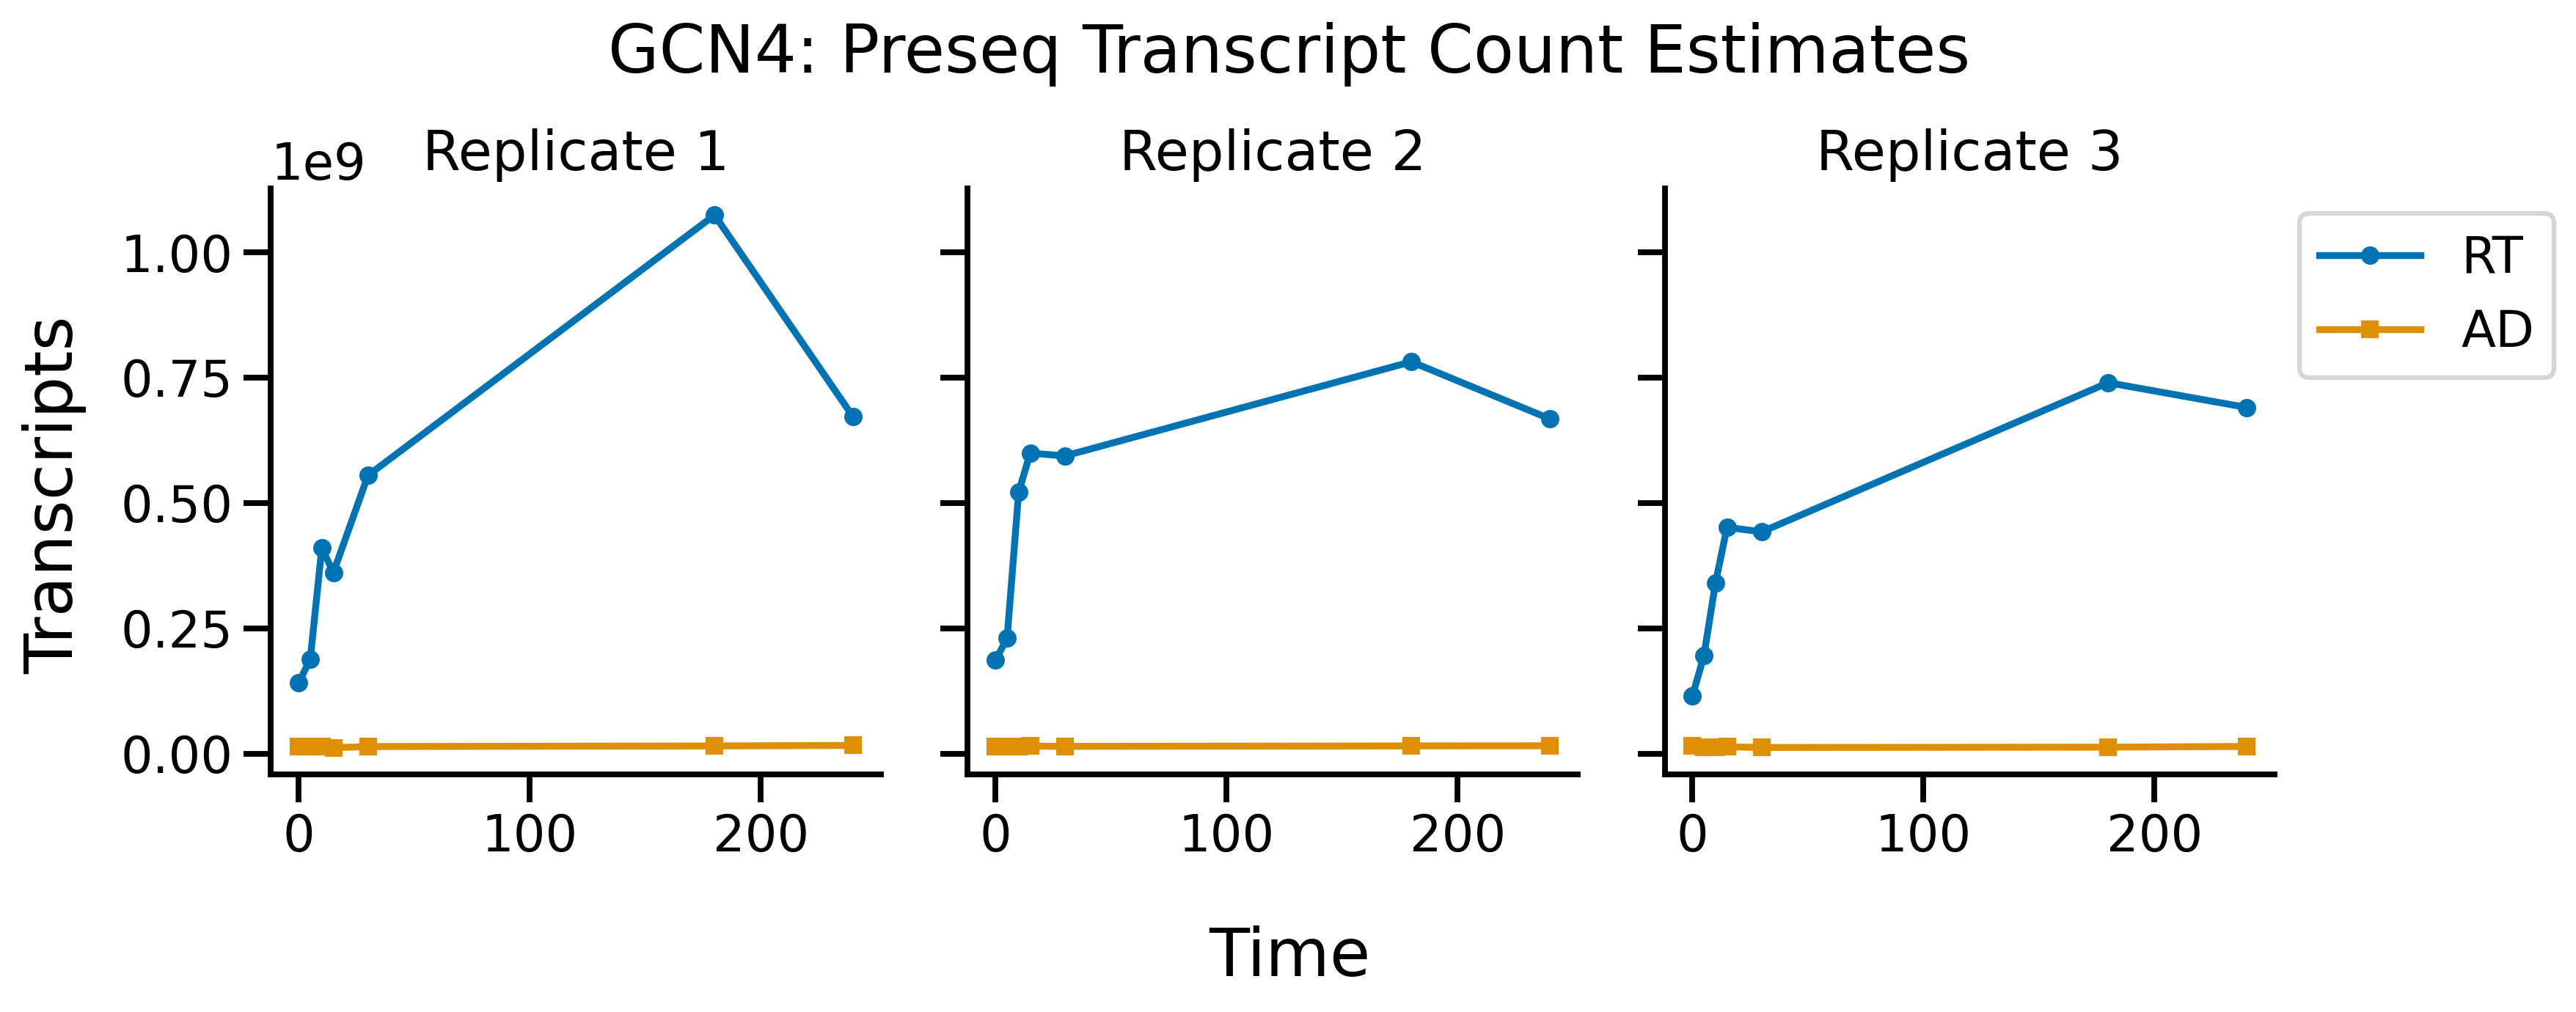

In [101]:
sns.set_context("talk")
palette = sns.color_palette("colorblind")

n_reps = 3
eps = 0  # pseudocount to avoid log(0)

fig, axes = plt.subplots(
    1, n_reps, figsize=(4 * n_reps, 5), sharex=True, sharey=True, dpi=300
)

if n_reps == 1:
    axes = [axes]

for ax, rep in zip(axes, range(1, n_reps + 1)):
    # RT
    g_rt = df[df["rep"] == rep].sort_values("time")
    ax.plot(
        g_rt["time"],
        g_rt["pop_size_estimate"] + eps,
        color=palette[0],
        marker="o",
        markersize=5,
        label="RT"
    )
    # ax.fill_between(
    #     g_rt["time"],
    #     g_rt["lower_ci"] + eps,
    #     g_rt["upper_ci"] + eps,
    #     color=palette[0],
    #     alpha=0.1
    # )

    # AD
    g_ad = AD_df[AD_df["rep"] == rep].sort_values("time")
    ax.plot(
        g_ad["time"],
        g_ad["pop_size_estimate"] + eps,
        color=palette[1],
        marker="s",
        markersize=5,
        label="AD"
    )
    # ax.fill_between(
    #     g_ad["time"],
    #     g_ad["lower_ci"] + eps,
    #     g_ad["upper_ci"] + eps,
    #     color=palette[1],
    #     alpha=0.1
    # )

    #ax.set_yscale("log")
    ax.set_title(f"Replicate {rep}")

# Global labels
fig.supxlabel("Time", y=0.05)
fig.supylabel("Transcripts", x=0.02)
fig.suptitle("GCN4: Preseq Transcript Count Estimates", y=0.93)

# Legend (only once)
axes[2].legend(loc="upper right",bbox_to_anchor = (1.5,1))

plt.tight_layout()
sns.despine()
plt.show()